<a href="https://colab.research.google.com/github/sbanty/Scipy-computing/blob/main/Assign2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib

In [ ]:
from google.colab import files
sunspot_auction_df = files.upload()

Saving sunspot_data.csv to sunspot_data.csv


In [ ]:
DATA_PATH = Path('sunspot_data.csv')   # Make sure file is uploaded
df = pd.read_csv(DATA_PATH)

In [ ]:
value_col = None
for c in df.columns:
    low = c.lower()
    if 'sun' in low or 'spot' in low or 'value' in low:
        value_col = c
        break
if value_col is None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    value_col = numeric_cols[0] if numeric_cols else df.columns[0]

In [ ]:
data = df[[value_col]].rename(columns={value_col:'value'})
data['value'] = pd.to_numeric(data['value'], errors='coerce').fillna(method='ffill').fillna(method='bfill').fillna(0)


/tmp/ipython-input-888985175.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['value'] = pd.to_numeric(data['value'], errors='coerce').fillna(method='ffill').fillna(method='bfill').fillna(0)


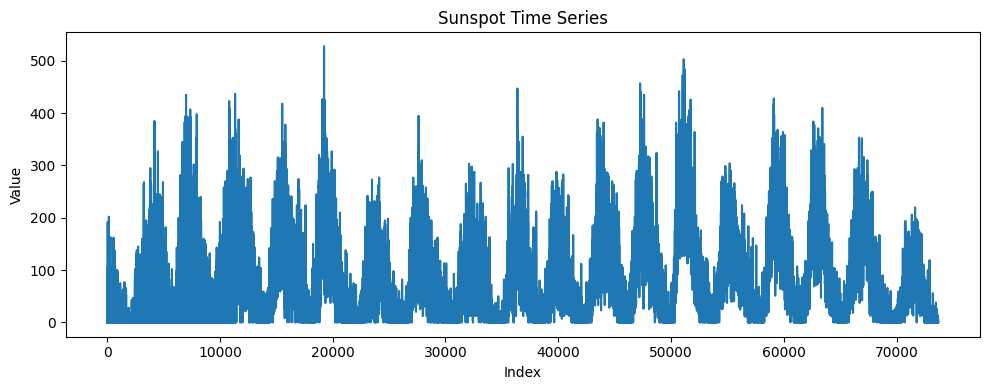

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(data['value'])
plt.title("Sunspot Time Series")
plt.xlabel("Index")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig("ts_plot.png")
plt.show()

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
values = data['value'].values.reshape(-1,1)
scaled = scaler.fit_transform(values)

def create_sequences(arr, look_back=30):
    X, y = [], []
    for i in range(len(arr) - look_back):
        X.append(arr[i:i+look_back])
        y.append(arr[i+look_back])
    return np.array(X), np.array(y)

LOOK_BACK = 30
X, y = create_sequences(scaled, LOOK_BACK)
split_idx = int(len(X)*0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

tf.random.set_seed(42)
model = Sequential([
    LSTM(64, input_shape=(LOOK_BACK, 1), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
EPOCHS = 30   # Increase this for better accuracy
BATCH_SIZE = 32
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)

# Save artifacts
model.save('sunspot_lstm.h5')
joblib.dump(scaler, 'sunspot_scaler.save')

Epoch 1/30
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - loss: 0.0062 - mae: 0.0507 - val_loss: 0.0014 - val_mae: 0.0266
Epoch 2/30
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 0.0042 - mae: 0.0407 - val_loss: 0.0015 - val_mae: 0.0275
Epoch 3/30
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 0.0042 - mae: 0.0404 - val_loss: 0.0013 - val_mae: 0.0255
Epoch 4/30
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - loss: 0.0041 - mae: 0.0399 - val_loss: 0.0012 - val_mae: 0.0252
Epoch 5/30
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - loss: 0.0040 - mae: 0.0394 - val_loss: 0.0011 - val_mae: 0.0242
Epoch 6/30
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 0.0040 - mae: 0.0392 - val_loss: 0.0011 - val_mae: 0.0238
Epoch 7/30
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 0.0039 - mae: 0.0389 - val_loss: 0.0010 - val_mae: 0.0226
Epoch 8/30
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 0.0038 - mae: 0.0387 - val_loss: 0.0010 - val_mae: 0.0231
Epoch 9/30
1843/1843 ━━━

['sunspot_scaler.save']

461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


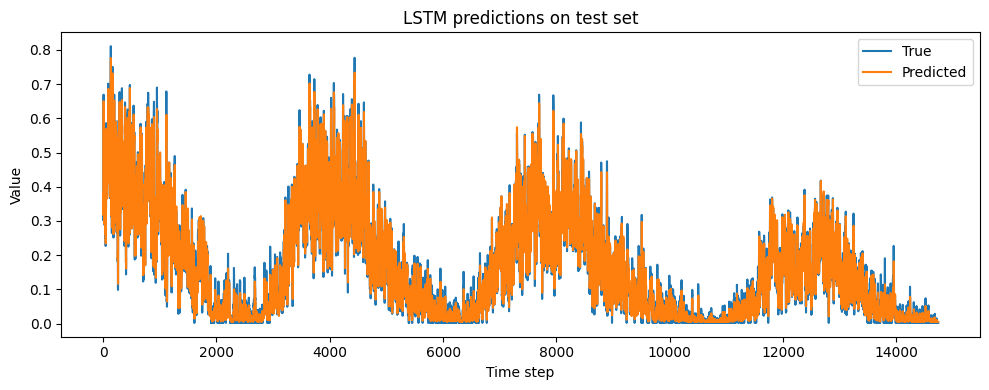

✅ Training complete. Files saved: sunspot_lstm.h5, sunspot_scaler.save, predictions.png, ts_plot.png


In [ ]:
pred = model.predict(X_test)

plt.figure(figsize=(10,4))
plt.plot(range(len(y_test)), y_test.flatten(), label='True')
plt.plot(range(len(pred)), pred.flatten(), label='Predicted')
plt.title("LSTM predictions on test set")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig("predictions.png")
plt.show()

print("✅ Training complete. Files saved: sunspot_lstm.h5, sunspot_scaler.save, predictions.png, ts_plot.png")